<a href="https://colab.research.google.com/github/moaaz-mohamedd/Autonomous-Vehicle-Perception-Module-Phase-2/blob/main/part5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

model.pth not found, using untrained model


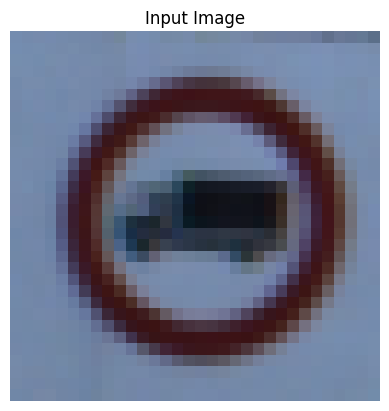

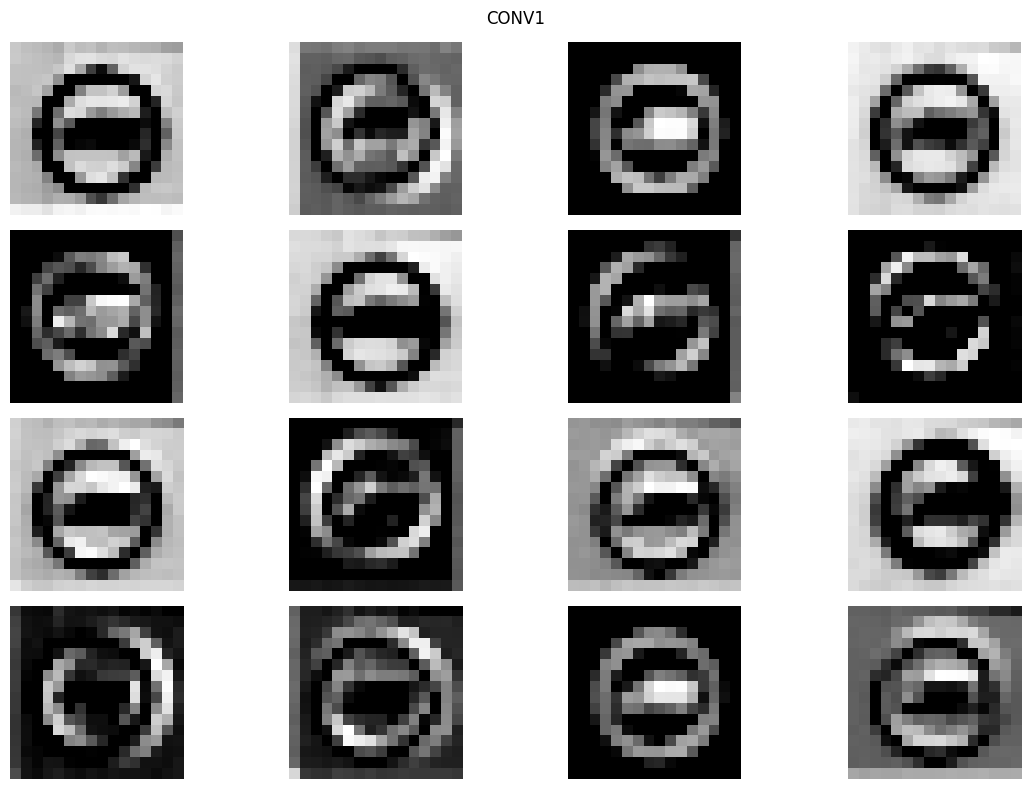

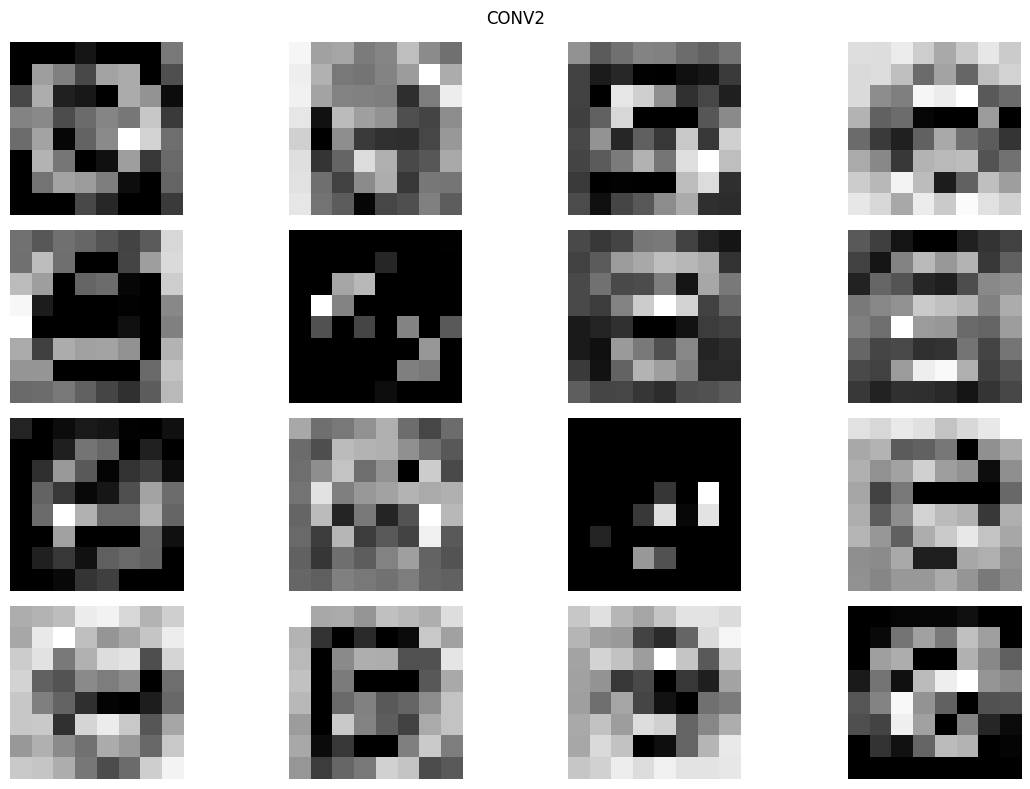

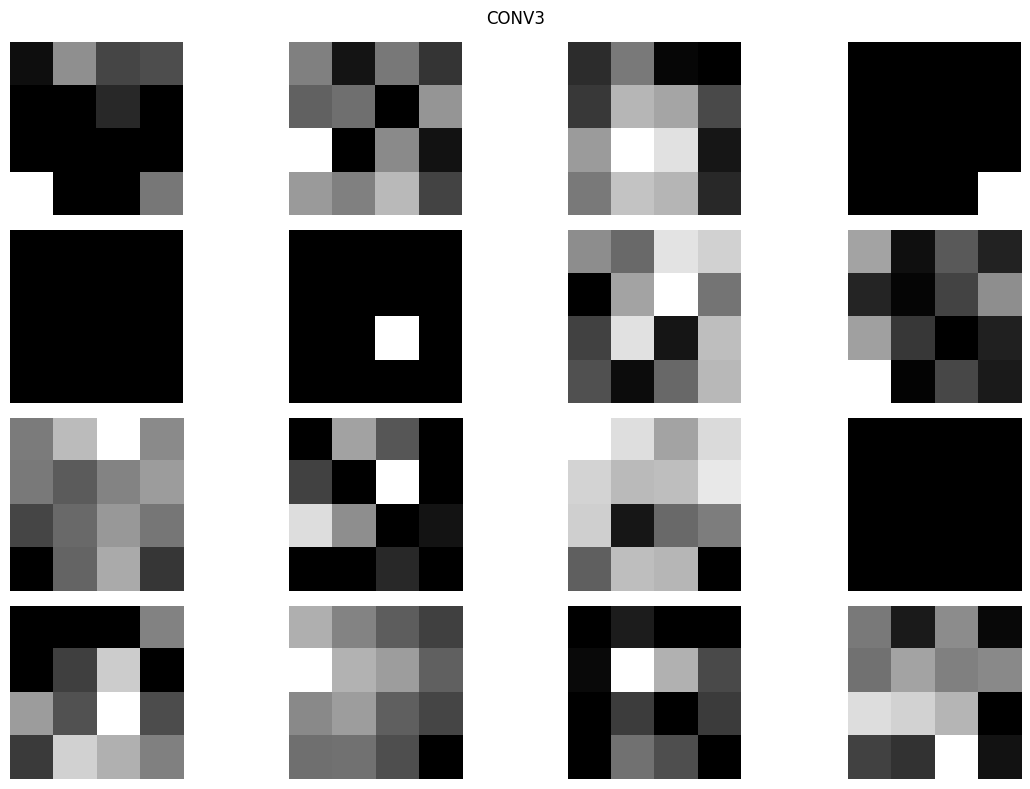

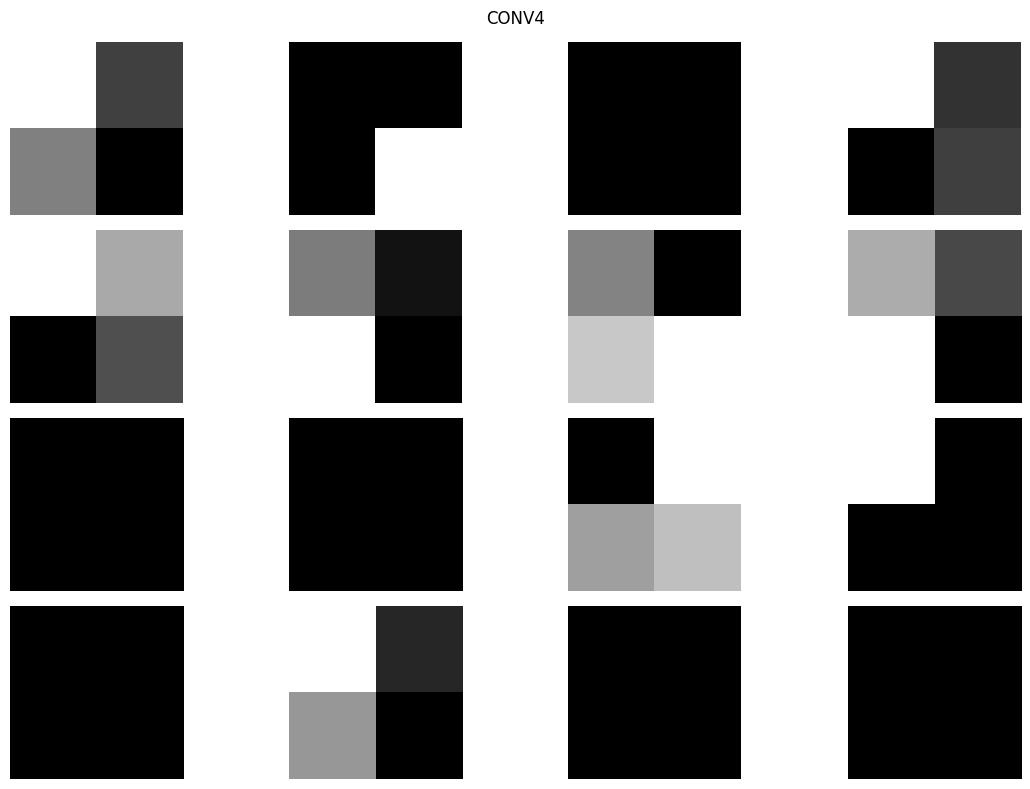

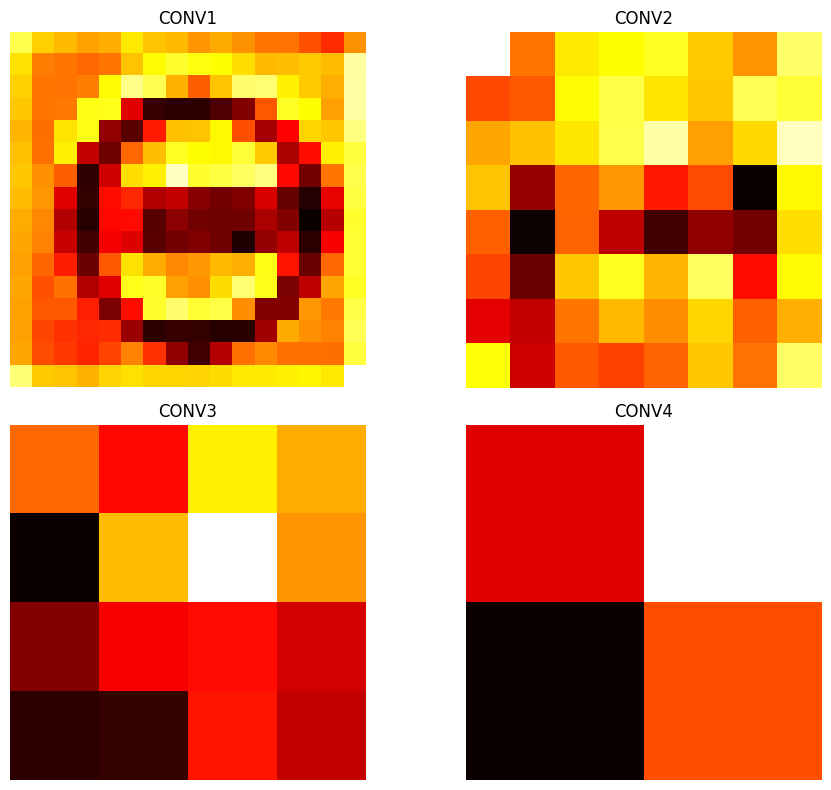

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214],
                         std=[0.2724, 0.2608, 0.2669])
])

test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,num_classes)

        self.activations = {}

    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        self.activations['conv1'] = x

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        self.activations['conv2'] = x

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        self.activations['conv3'] = x

        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        self.activations['conv4'] = x

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_activations(self):
        return self.activations

    def clear_activations(self):
        self.activations = {}

model = TrafficSignCNN(num_classes=43).to(device)

if os.path.exists("model.pth"):
    try:
        state_dict = torch.load("model.pth", map_location=device)
        model.load_state_dict(state_dict)
        print("Model loaded successfully")
    except:
        print("Model mismatch, running with random weights")
else:
    print("model.pth not found, using untrained model")

model.eval()

def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3,1,1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3,1,1)
    img = img.cpu() * std + mean
    return torch.clamp(img, 0, 1)

def show_input(img_tensor):
    img = denormalize(img_tensor[0]).permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

def visualize_feature_maps(model, image_tensor, layer_name, max_maps=16):
    model.clear_activations()

    with torch.no_grad():
        _ = model(image_tensor)

    activations = model.get_activations()
    fmap = activations[layer_name][0].cpu().numpy()

    num_maps = min(max_maps, fmap.shape[0])
    cols = 4
    rows = int(np.ceil(num_maps / cols))

    plt.figure(figsize=(12,8))

    for i in range(num_maps):
        plt.subplot(rows, cols, i+1)
        img = fmap[i]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(layer_name.upper())
    plt.tight_layout()
    plt.show()

def visualize_all_layers(model, image_tensor):
    for layer in ['conv1','conv2','conv3','conv4']:
        visualize_feature_maps(model, image_tensor, layer)

def visualize_average_maps(model, image_tensor):
    model.clear_activations()

    with torch.no_grad():
        _ = model(image_tensor)

    activations = model.get_activations()

    plt.figure(figsize=(10,8))

    for i, layer in enumerate(['conv1','conv2','conv3','conv4']):
        fmap = activations[layer][0].cpu().numpy()
        avg_map = fmap.mean(axis=0)
        avg_map = (avg_map - avg_map.min()) / (avg_map.max() - avg_map.min() + 1e-8)

        plt.subplot(2,2,i+1)
        plt.imshow(avg_map, cmap='hot')
        plt.title(layer.upper())
        plt.axis('off')

    plt.tight_layout()
    plt.show()

images, labels = next(iter(test_loader))
sample_img = images[0].unsqueeze(0).to(device)

show_input(sample_img)
visualize_all_layers(model, sample_img)
visualize_average_maps(model, sample_img)

model.pth not found, using untrained model

Single Example


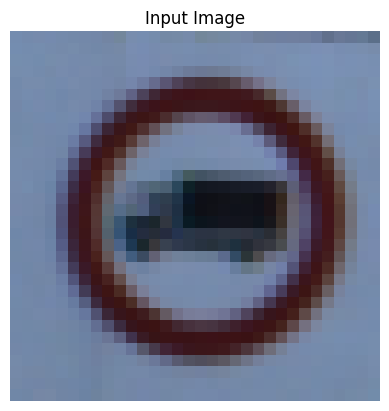

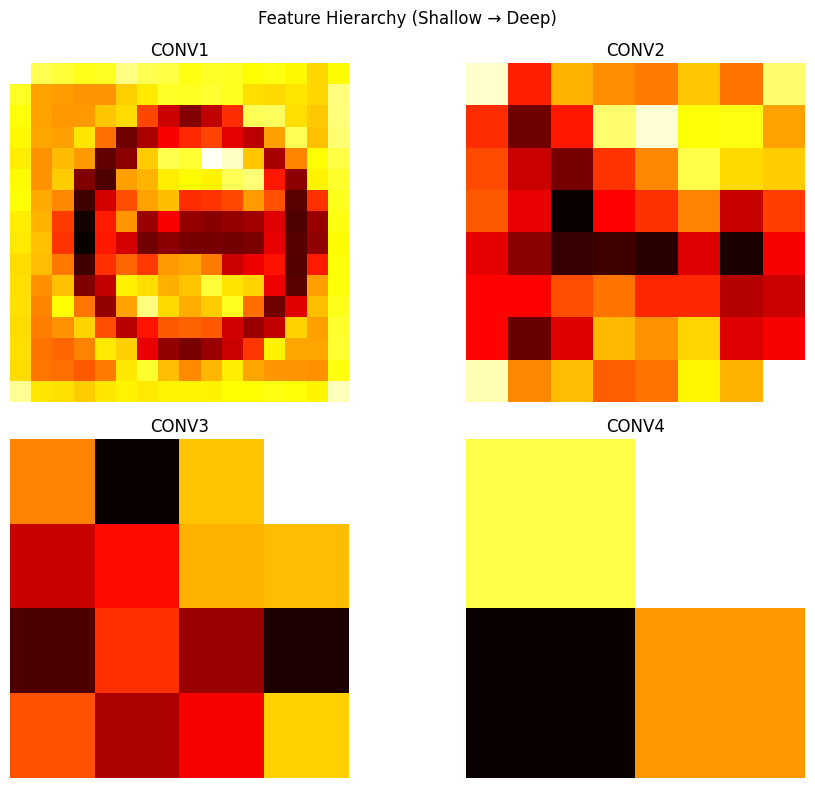


Multiple Examples

Sample 1


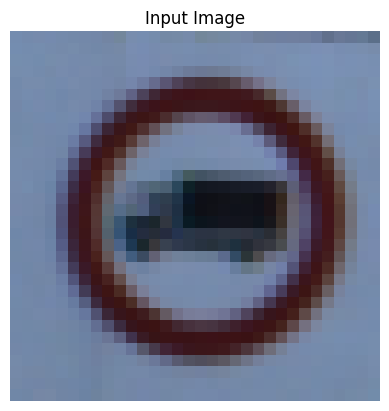

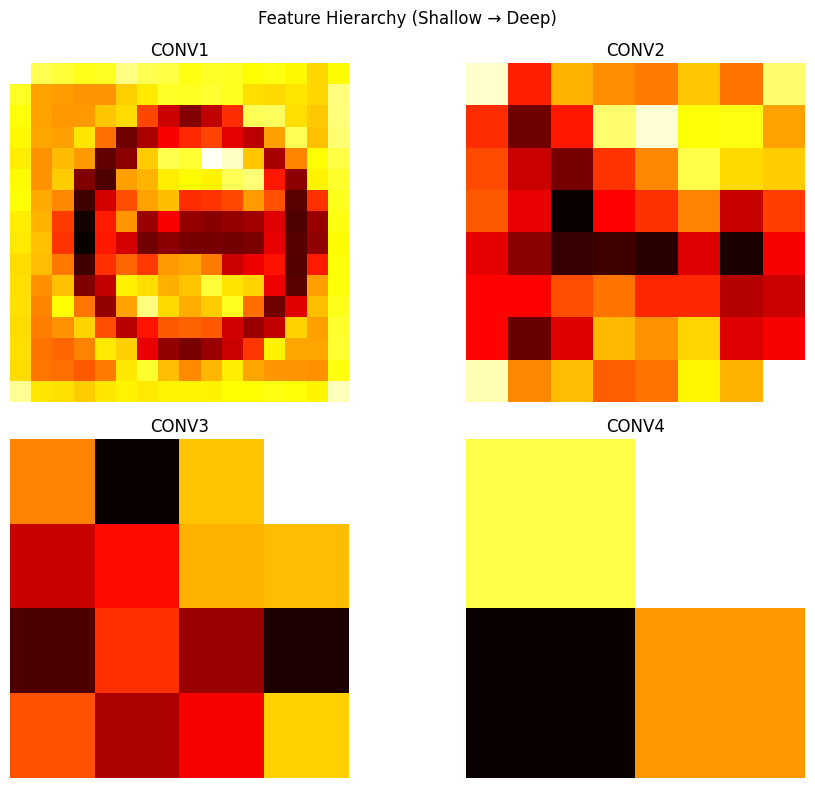

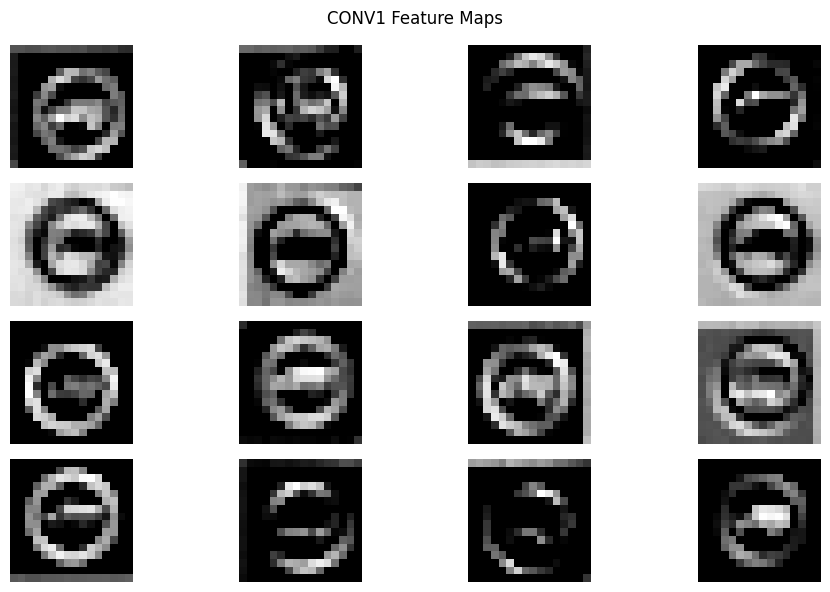


Sample 2


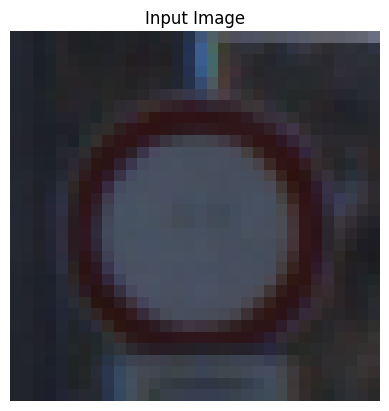

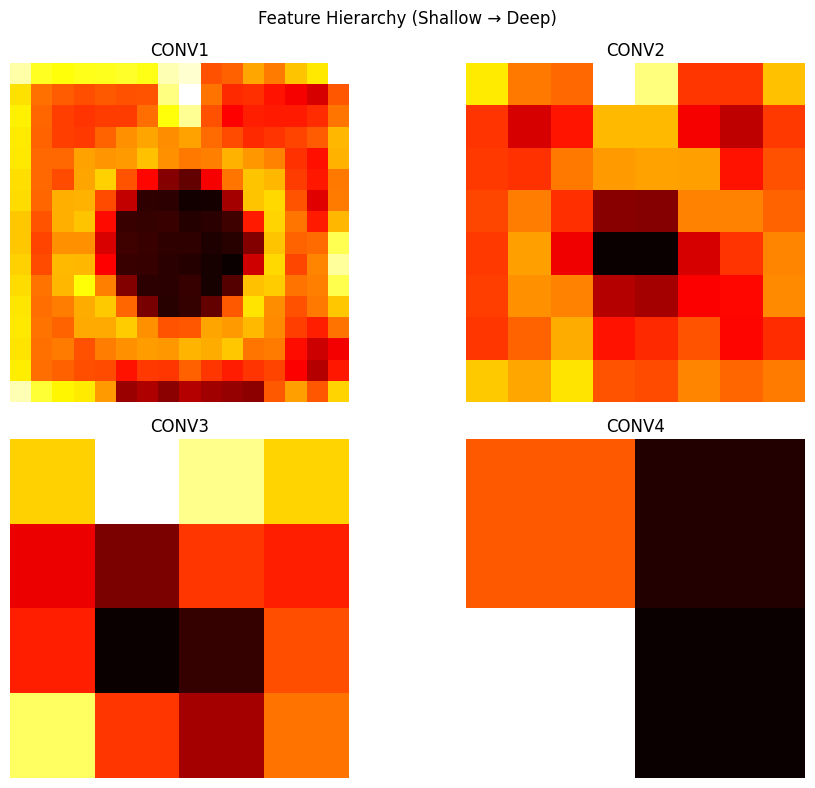

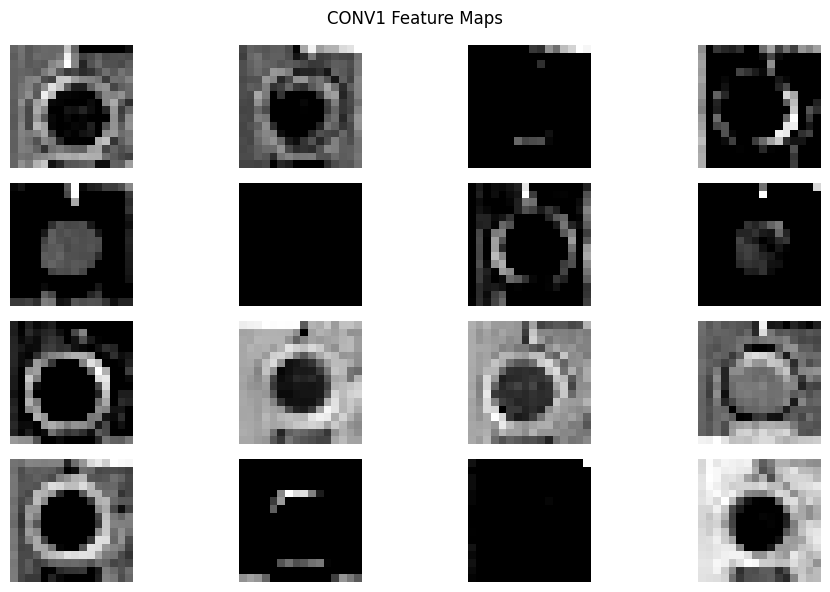


Sample 3


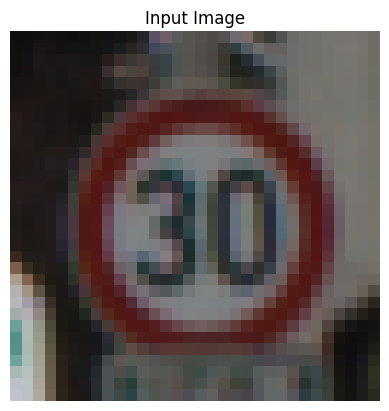

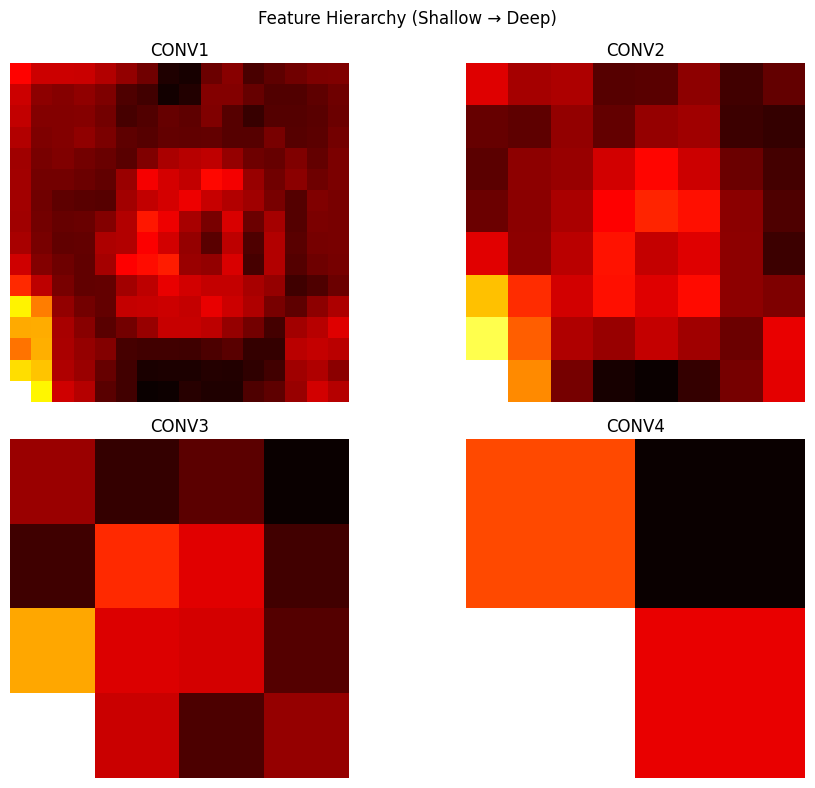

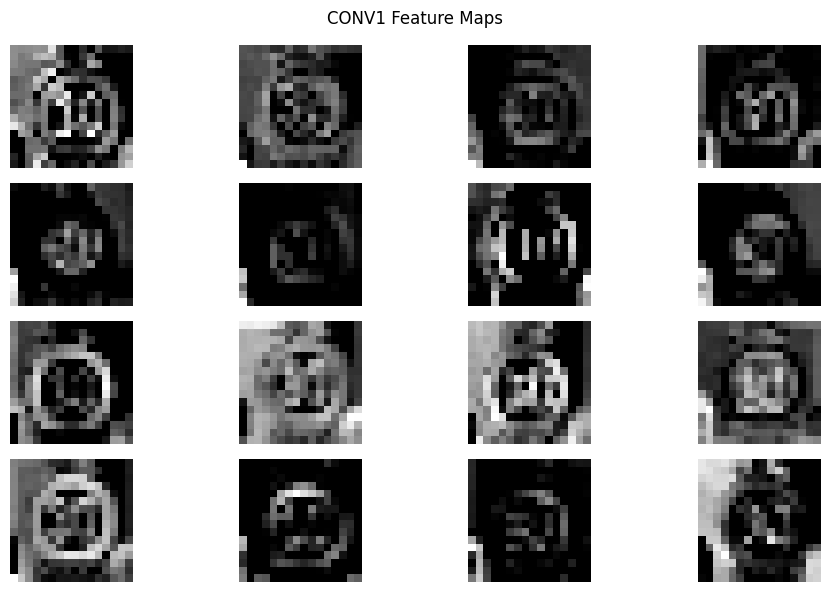

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214],
                         std=[0.2724, 0.2608, 0.2669])
])

test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,num_classes)

        self.activations = {}

    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        self.activations['conv1'] = x

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        self.activations['conv2'] = x

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        self.activations['conv3'] = x

        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        self.activations['conv4'] = x

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_activations(self):
        return self.activations

    def clear_activations(self):
        self.activations = {}

model = TrafficSignCNN().to(device)

if os.path.exists("model.pth"):
    try:
        model.load_state_dict(torch.load("model.pth", map_location=device))
        print("Model loaded successfully")
    except:
        print("Model mismatch, using random weights")
else:
    print("model.pth not found, using untrained model")

model.eval()

def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3,1,1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3,1,1)
    img = img.cpu() * std + mean
    return torch.clamp(img, 0, 1)

def show_input(img_tensor):
    img = denormalize(img_tensor[0]).permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

def visualize_layer_maps(model, image_tensor, layer_name):
    model.clear_activations()

    with torch.no_grad():
        _ = model(image_tensor)

    fmap = model.get_activations()[layer_name][0].cpu().numpy()

    num_maps = min(16, fmap.shape[0])
    cols = 4
    rows = int(np.ceil(num_maps / cols))

    plt.figure(figsize=(10,6))

    for i in range(num_maps):
        plt.subplot(rows, cols, i+1)
        img = fmap[i]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"{layer_name.upper()} Feature Maps")
    plt.tight_layout()
    plt.show()

def visualize_progression(model, image_tensor):
    model.clear_activations()

    with torch.no_grad():
        _ = model(image_tensor)

    activations = model.get_activations()

    plt.figure(figsize=(10,8))

    for i, layer in enumerate(['conv1','conv2','conv3','conv4']):
        fmap = activations[layer][0].cpu().numpy()
        avg_map = fmap.mean(axis=0)
        avg_map = (avg_map - avg_map.min()) / (avg_map.max() - avg_map.min() + 1e-8)

        plt.subplot(2,2,i+1)
        plt.imshow(avg_map, cmap='hot')
        plt.title(layer.upper())
        plt.axis('off')

    plt.suptitle("Feature Hierarchy (Shallow → Deep)")
    plt.tight_layout()
    plt.show()

def visualize_multiple_samples(model, loader, num_samples=3):
    data_iter = iter(loader)

    for i in range(num_samples):
        images, labels = next(data_iter)
        img = images[0].unsqueeze(0).to(device)

        print(f"\nSample {i+1}")
        show_input(img)
        visualize_progression(model, img)
        visualize_layer_maps(model, img, 'conv1')

images, labels = next(iter(test_loader))
sample_img = images[0].unsqueeze(0).to(device)

print("\nSingle Example")
show_input(sample_img)
visualize_progression(model, sample_img)

print("\nMultiple Examples")
visualize_multiple_samples(model, test_loader, num_samples=3)